In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import pandas as pd

def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx, array[idx]


In [298]:
file_caII = '/Volumes/ViSP_External/CaII_11Aug2024_Cclass_newcalib.npz'
file_hbeta = '/Volumes/ViSP_External/Hbeta_11Aug2024_Cclass_newcalib.npz'
ViSPcoords = '/Users/coletamburri/Desktop/DKIST_Flares/11_Aug_2024_Cclass_Flare/Processed_ViSP_VBI_11Aug2024/ViSPcoords_newcalib.npz'


hbeta_low =370
hbeta_core = 470
hbeta_high = 570

caII_low = 480 #570 for first calibration pre March 6
caII_core = 565
caII_high = 690

hepsilon_low = 685
hepsilon_high = 810

nsteps = 91
start = 57 #143 for saved Hbeta spectra
nframes = 10

In [305]:
wave_hbeta[hbeta_core]-wave_hbeta[hbeta_low]

np.float64(0.11007089530249914)

In [7]:
res_caII = np.load(file_caII)
res_hbeta = np.load(file_hbeta)
dkist_coords = np.load(ViSPcoords)

In [25]:
xarr_caII = dkist_coords['xarr_caII']
yarr_caII = dkist_coords['yarr_caII']

xarr_hbeta = dkist_coords['xarr_hbeta'][:-1]
yarr_hbeta = dkist_coords['yarr_hbeta']

In [215]:
flare_arr_caII = res_caII['flare']
wave_caII = res_caII['wl']

flare_arr_hbeta = res_hbeta['flare']
wave_hbeta = res_hbeta['wl']



OSError: [Errno 5] Input/output error

In [217]:
times=res_caII['time'];
times

OSError: [Errno 5] Input/output error

In [218]:
np.shape(flare_arr_hbeta)

(999, 902, 2548)

In [18]:
np.shape(flare_arr_caII)

(999, 915, 2556)

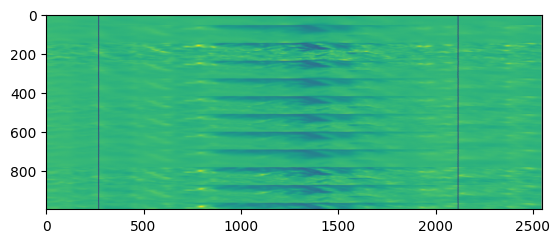

In [19]:
plt.imshow(flare_arr_hbeta[:,300,:])

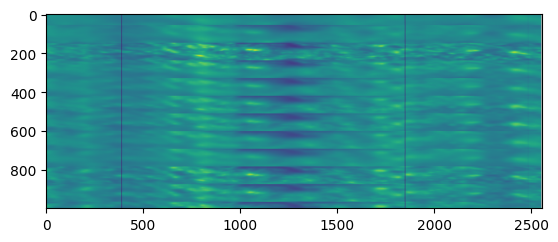

In [21]:
plt.imshow(flare_arr_caII[:,300,:])

In [299]:
bestseeingcaII_red = flare_arr_caII[148:239,caII_high,:]
bestseeingcaII_core = flare_arr_caII[148:239,caII_core,:]
bestseeingcaII_blue = flare_arr_caII[148:239,caII_low,:]

bestseeinghbeta_red = flare_arr_hbeta[148:239,hbeta_high,:]
bestseeinghbeta_core = flare_arr_hbeta[148:239,hbeta_core,:]
bestseeinghbeta_blue = flare_arr_hbeta[148:239,hbeta_low,:]

In [300]:
wave_caII[caII_low]-396.85

np.float64(-0.07899525088612336)

In [327]:
ls = np.flip([49,58,77,78,80,72,75,60])
ms= np.flip([1315,1365,1220,1150,1050,1310,780,650])

x_select = []
y_select = []
for i in range(len(ls)):
    x_select.append(xarr_caII[ls[i]])
    y_select.append(yarr_caII[ms[i]])

#convert these spatial coordinates to coordinates in the other frame
x_other_inds = []
y_other_inds = []

for i in range(len(x_select)):
    indsx,valx = find_nearest(xarr_hbeta,x_select[i])
    indsy,valy = find_nearest(yarr_hbeta,y_select[i])

    x_other_inds.append(indsx)
    y_other_inds.append(indsy)

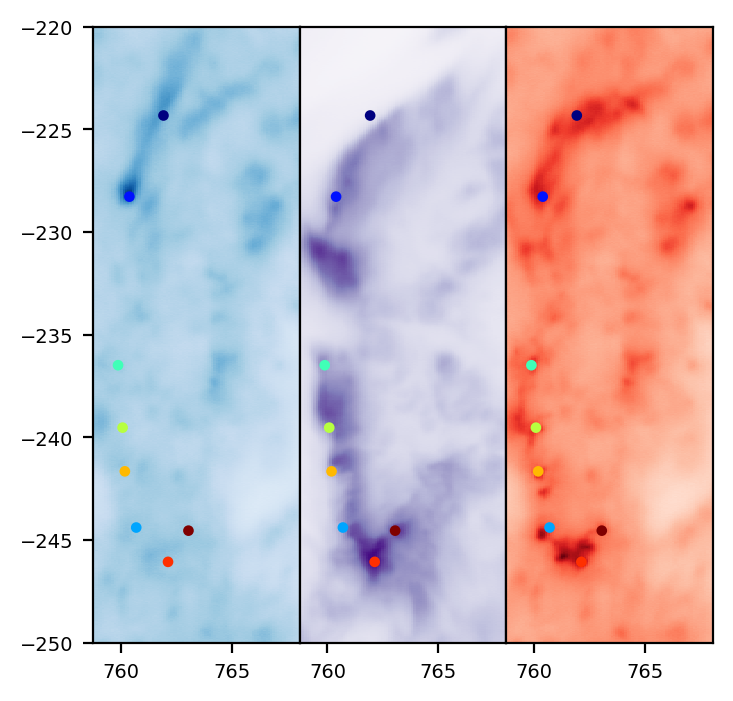

In [328]:
n_points = 8
colors = plt.cm.jet(np.linspace(0,1,n_points))
#region A, region B, region C, Region D1, region D2, region Asymm, region Asymm with red,  region Bkern, region Bblue, region Binit
xsel = xarr_caII[ls]
ysel = yarr_caII[ms]

fig,ax=plt.subplots(1,3,figsize=(4,4),dpi=200)
ax.flatten()[0].pcolormesh(xarr_caII,yarr_caII,np.transpose(bestseeingcaII_blue),cmap='Blues')

ax.flatten()[0].scatter(xsel,ysel,8,color=colors)
ax.flatten()[0].set_ylim([-250,-220])

ax.flatten()[1].pcolormesh(xarr_caII,yarr_caII,np.transpose(bestseeingcaII_core),cmap='Purples')
ax.flatten()[1].set_ylim([-250,-220])

ax.flatten()[1].scatter(xsel,ysel,8,color=colors)
ax.flatten()[1].set_yticks([])

ax.flatten()[2].pcolormesh(xarr_caII,yarr_caII,np.transpose(bestseeingcaII_red),cmap='Reds')
ax.flatten()[2].set_ylim([-250,-220])

ax.flatten()[2].scatter(xsel,ysel,8,color=colors)
ax.flatten()[2].set_yticks([])

ax.flatten()[0].tick_params(axis='x', labelsize=7)
ax.flatten()[1].tick_params(axis='x', labelsize=7)
ax.flatten()[2].tick_params(axis='x', labelsize=7)

ax.flatten()[0].tick_params(axis='y', labelsize=7)



fig.subplots_adjust(wspace=0)


In [329]:
xarr_hbeta[x_other_inds]

array([761.92839166, 760.39123431, 760.69866578, 759.87884853,
       760.08380284, 760.18628   , 762.13334597, 763.05564038])

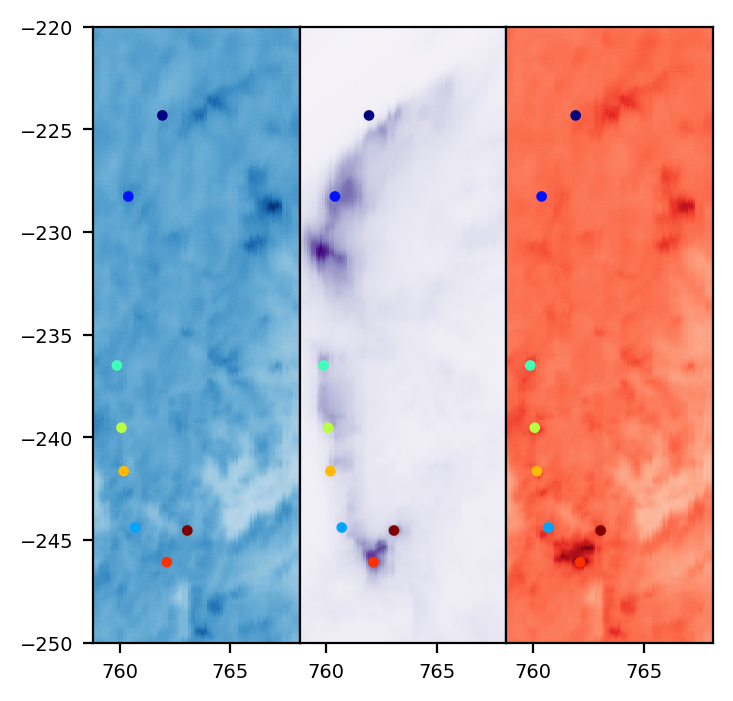

In [330]:
n_points = 8
colors = plt.cm.jet(np.linspace(0,1,n_points))
#region A, region B, region C, Region D1, region D2, region Asymm, region Asymm with red,  region Bkern, region Bblue, region Binit
xsel = xarr_hbeta[x_other_inds]
ysel = yarr_hbeta[y_other_inds]

fig,ax=plt.subplots(1,3,figsize=(4,4),dpi=200)
ax.flatten()[0].pcolormesh(xarr_hbeta,yarr_hbeta,np.transpose(bestseeinghbeta_blue),cmap='Blues')

ax.flatten()[0].scatter(xsel,ysel,8,color=colors)
ax.flatten()[0].set_ylim([-250,-220])

ax.flatten()[1].pcolormesh(xarr_hbeta,yarr_hbeta,np.transpose(bestseeinghbeta_core),cmap='Purples')
ax.flatten()[1].set_ylim([-250,-220])

ax.flatten()[1].scatter(xsel,ysel,8,color=colors)
ax.flatten()[1].set_yticks([])

ax.flatten()[2].pcolormesh(xarr_hbeta,yarr_hbeta,np.transpose(bestseeinghbeta_red),cmap='Reds')
ax.flatten()[2].set_ylim([-250,-220])

ax.flatten()[2].scatter(xsel,ysel,8,color=colors)
ax.flatten()[2].set_yticks([])

ax.flatten()[0].tick_params(axis='x', labelsize=7)
ax.flatten()[1].tick_params(axis='x', labelsize=7)
ax.flatten()[2].tick_params(axis='x', labelsize=7)

ax.flatten()[0].tick_params(axis='y', labelsize=7)



fig.subplots_adjust(wspace=0)


In [331]:
def veltrans(x):
    return ((((x+lamb0)/lamb0)-1)*c)/mu

def veltrans2(x):
    return ((((x+lamb0)/lamb0)-1)*c)/mu2

def wltrans(x):
    return ((((x/c)+1)*lamb0)-lamb0)

In [332]:
labeltimes=[]

for i in range(10):
    labeltimes.append(times[57+91*i][-15:-7])

In [333]:
labeltimes

['22:32:58',
 '22:33:19',
 '22:33:40',
 '22:34:01',
 '22:34:22',
 '22:34:43',
 '22:35:04',
 '22:35:25',
 '22:35:46',
 '22:36:07']

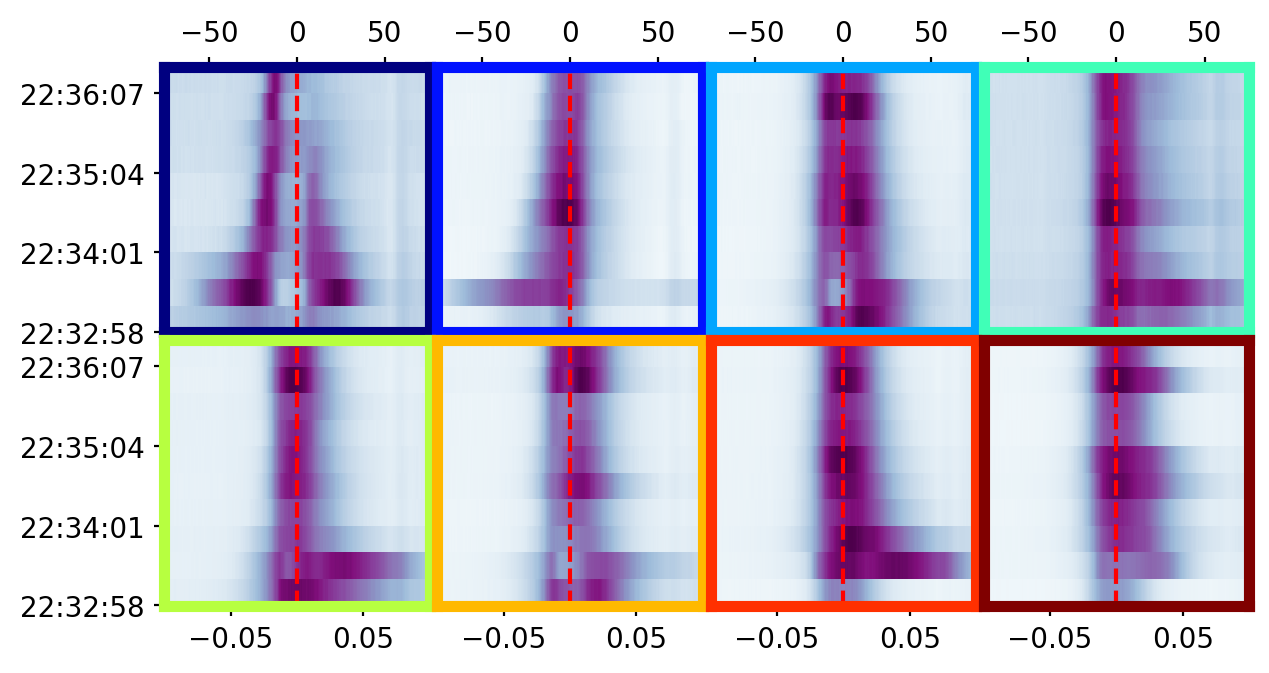

In [334]:
fig,ax=plt.subplots(2,4,figsize=(7,3.5),dpi=200)
lamb0=396.85
c=2.99e5
mu=1
for j in range(len(ls)):
    l=ls[j]
    m=ms[j]
    caiipcolor =[]
    for i in np.arange(0,10*91,91):
        if i == 91:
            caiipcolor.append(flare_arr_caII[l+i+57,:,m]/1.5)

        else:
            caiipcolor.append(flare_arr_caII[l+i+57,:,m])

    
    ax.flatten()[j].pcolormesh(wave_caII-lamb0,np.arange(0,10*91,91),caiipcolor,cmap='BuPu')
    ax.flatten()[j].set_xlim([396.75-lamb0,396.95-lamb0])
    ax.flatten()[j].set_yticks([])
    ax.flatten()[j].set_xticks([-0.05,0.05])
    ax.flatten()[j].axvline(0,c='red',linestyle='dashed')

    if j < 4:
       #ax.flatten()[j].set_xticks([]) 
       secaxx = ax.flatten()[j].secondary_xaxis('top', functions=(veltrans,wltrans))
       #secaxx.set_xlabel(r'Velocity $[km\; s^{-1}]$')
       #secaxx.set_xticks([-120,-80,-40,0,40,80,120])
    for spine in ax.flatten()[j].spines.values():
        spine.set_color(colors[j])
        spine.set_linewidth(4) # Optional: make it thicker
    ax.flatten()[j].xaxis.get_major_formatter().set_useOffset(False)

    if j == 0 or j == 4:
        ax.flatten()[j].set_yticks([(0*91)-45,(3*91)-45,(6*91)-45,(9*91)-45],labeltimes[0:10:3])
    else:
        ax.flatten()[j].set_yticks([])


fig.subplots_adjust(wspace=0.029)
fig.subplots_adjust(hspace=0.03)

In [335]:
np.arange(0,12,3)

array([0, 3, 6, 9])

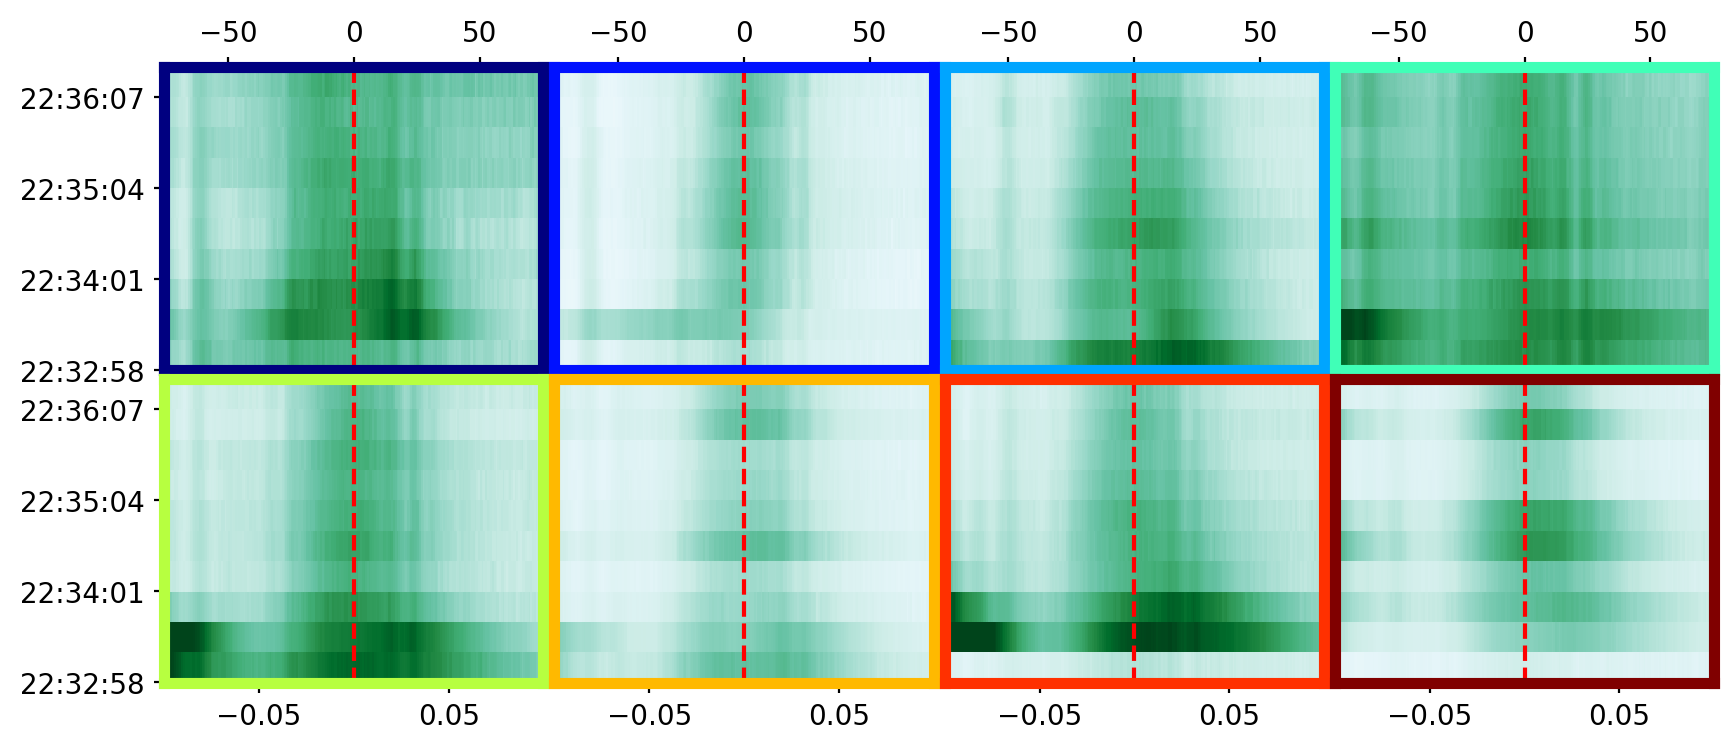

In [336]:
fig,ax=plt.subplots(2,4,figsize=(10,4),dpi=200)
lamb0=397.01
c=2.99e5
mu=1
for j in range(len(ls)):
    l=ls[j]
    m=ms[j]
    caiipcolor =[]
    for i in np.arange(0,10*91,91):
        if i == 91:
            caiipcolor.append(flare_arr_caII[l+i+57,:,m]/2)

        else:
            caiipcolor.append(flare_arr_caII[l+i+57,:,m])
    ax.flatten()[j].pcolormesh(wave_caII-lamb0,np.arange(0,10*91,91),caiipcolor,cmap='BuGn',vmax=2.5*flare_arr_caII[l+i+57,750,m])
    ax.flatten()[j].set_xlim([-.1,.1])
    ax.flatten()[j].set_xticks([-0.05,0.05])
    ax.flatten()[j].axvline(0,c='red',linestyle='dashed')
    if j < 4:
       secaxx = ax.flatten()[j].secondary_xaxis('top', functions=(veltrans,wltrans))
       ax.flatten()[j].set_xticks([]) 
    for spine in ax.flatten()[j].spines.values():
        spine.set_color(colors[j])
        spine.set_linewidth(4) # Optional: make it thicker

    ax.flatten()[j].xaxis.get_major_formatter().set_useOffset(False)

    if j == 0 or j == 4:
        ax.flatten()[j].set_yticks([(0*91)-45,(3*91)-45,(6*91)-45,(9*91)-45],labeltimes[0:10:3])
    else:
        ax.flatten()[j].set_yticks([])


fig.subplots_adjust(wspace=0.029)
fig.subplots_adjust(hspace=0.03)

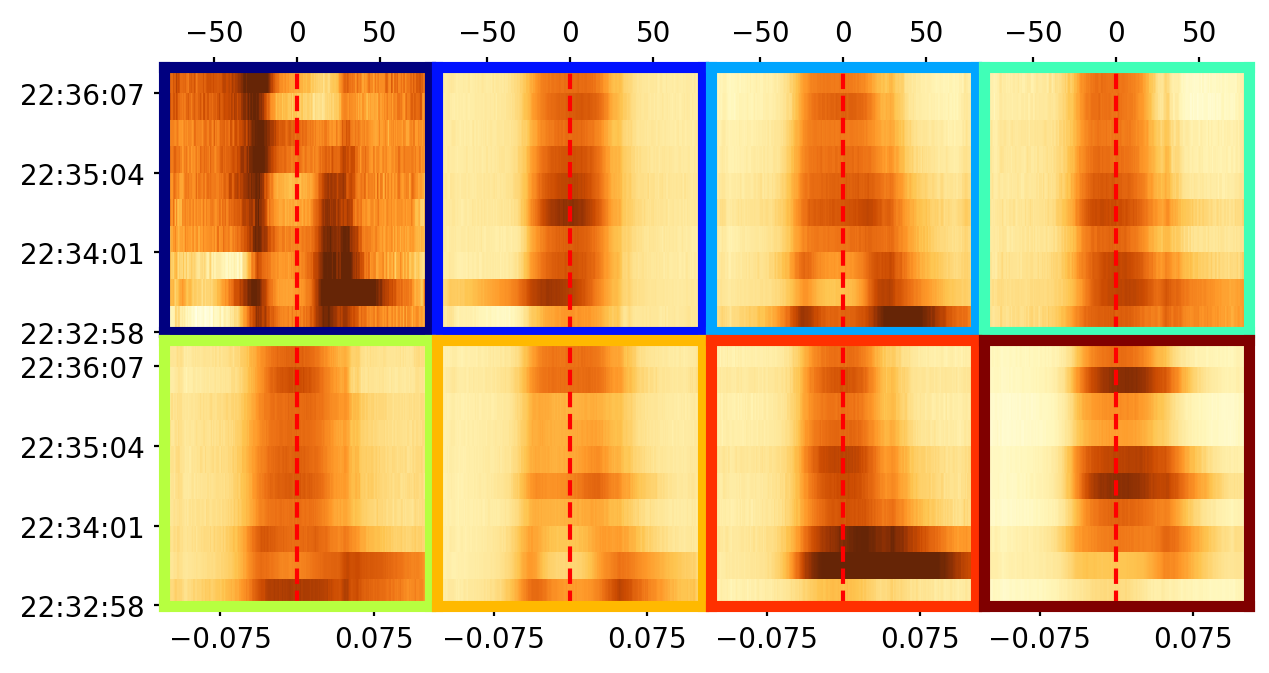

In [337]:
fig,ax=plt.subplots(2,4,figsize=(7,3.5),dpi=200)
lamb0=486.1375
c=2.99e5
mu=1
for j in range(len(ls)):
    l=x_other_inds[j]
    m=y_other_inds[j]
    hbetapcolor =[]
    for i in np.arange(0,10*91,91):
        if i == 91:
            hbetapcolor.append(flare_arr_hbeta[l+i+57,:,m]/2)

        else:
            hbetapcolor.append(flare_arr_hbeta[l+i+57,:,m])
    ax.flatten()[j].pcolormesh(wave_hbeta-lamb0,np.arange(0,10*91,91),hbetapcolor,cmap='YlOrBr',vmax=2*flare_arr_hbeta[l+i+57,450,m])
    ax.flatten()[j].set_xlim([-0.13,0.13])
    ax.flatten()[j].set_yticks([])
    ax.flatten()[j].set_xticks([-0.075,0.075])

    ax.flatten()[j].axvline(0,c='red',linestyle='dashed')
    if j < 4:
       secaxx = ax.flatten()[j].secondary_xaxis('top', functions=(veltrans,wltrans))
       ax.flatten()[j].set_xticks([]) 
    for spine in ax.flatten()[j].spines.values():
        spine.set_color(colors[j])
        spine.set_linewidth(4) # Optional: make it thicker

    if j == 0 or j == 4:
        ax.flatten()[j].set_yticks([(0*91)-45,(3*91)-45,(6*91)-45,(9*91)-45],labeltimes[0:10:3])
    else:
        ax.flatten()[j].set_yticks([])


fig.subplots_adjust(wspace=0.029)
fig.subplots_adjust(hspace=0.03)

In [343]:
# similar plotting but for kmeans - Ca II H
manyscan=1 # want to plot ~10 scans around the good-seeing scan

line=0 # this is just an index for Ca II H. In the .py file I used for the clustering, this is 1 if H-beta.  Don't worry about this key...
n_clusters0=35 # number of clusters
colors = plt.cm.turbo(np.linspace(0,1,n_clusters0)) #colormap for plotting

# define indices bounding the lines we could cluster
hbeta_low =353
hbeta_high = 640
caII_low = 480 #570 for first calibration pre March 6
caII_high = 690
hepsilon_low = 685
hepsilon_high = 810

#cutoff0 = 1.5 # for more than one frame
if line == 1:
    cutoff0=9 # for h-beta
    if manyscan:
        cutoff0=5 
if line == 0: # for ca II
    cutoff0=2.5
    if manyscan:
        cutoff0=2.5 

# number of clusters
if line == 1:
    n_clusters0 = 35 # 10 works for hbeta, 6 for Ca II H seems to be all that's needed, 6 also for h-ep
if line == 0:
    n_clusters0 = 35

#spatial limits (along slit) of ribbon -different for arms 1 and 2
if line == 1:
    startspace = 300 
    endspace = 1800 
if line == 0:
    startspace = 300 
    endspace = 1700
    
# define rest wavelengths
if line == 1:
    cent= 486.1375
if line == 0:
    cent = 396.85
    
# define limits of line; essentially the blue and red bounds of spectral range to cluster
if line == 1:
    linelow = hbeta_low
    linehigh = hbeta_high
if line == 0:
    linelow = caII_low
    linehigh = caII_high

# function to convert observed wavelength to velocity
def find_velocity(rest_wl,obs_wl):
    c= 299792458 # m/s
    
    return c*(obs_wl-rest_wl)/(obs_wl)

base = '/Users/coletamburri/Desktop/11Aug2024_kmeans_result_21May2026/' # change to directory you need


In [344]:
#load clustering file
km_file = np.load(base+'CaIIH_clustering_result.npz',allow_pickle='True')

#extract variables from clustering file
xarr_ch=km_file['xarr_ch'] # x coordinates for pcolormesh
yarr_ch=km_file['yarr_ch'] # y coordinates for pcolormesh
frame_line=km_file['frame_line'] # scans of interest, with along-slit direction limited just to what we want to see
normprofiles_line=km_file['normprofiles_line'] # normalized spectral line profiles
times=km_file['times'] # times for each ViSP slit position
km01=km_file['km0'] # numpy array containing the KMeansClusterer object (nltk)
labels0=km_file['labels0'] # numpy array containing the cluster number for each pixel
wave=km_file['wave'] # wavelength array for chosen arm
sortedinds=km_file['sortedinds'] # cluster indices sorted by weighted mean (blueshifted to redshifted
selwls=km_file['selwls'] # wavelength array for chosen line only
sortedwls=km_file['sortedwls'] # location of calculated line center (0 is the first index in "selwls")

#read pandas dataframe containing clusters from csv
# contains the mask info, including the x values, y values, and cluster number corresponding to each pixel
df_mask = pd.read_csv(base+'CaIIH_df.csv') 

#the result of kmeans is a weird class from the nltk package; extract the necessary info with this line
km0 = km01.item()   # extract the object so we can read variables directly as attributes of the class
cc = km0.cluster_centers_

/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator KMeans from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


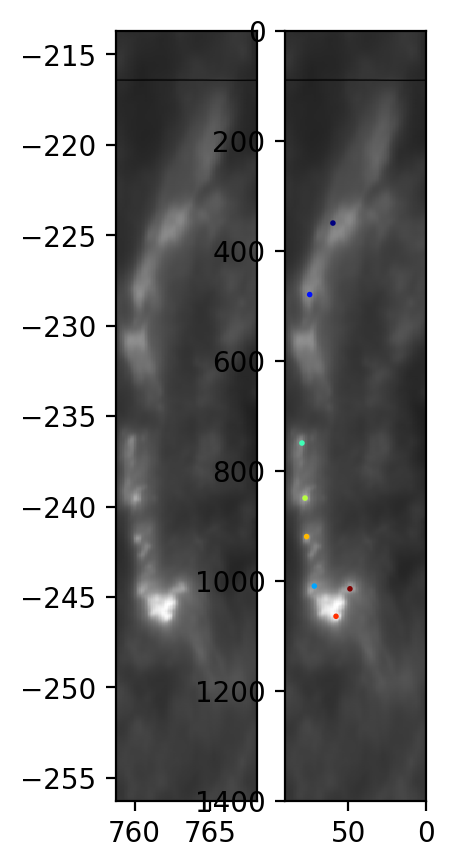

In [345]:
n_points = 8
colors = plt.cm.jet(np.linspace(0,1,n_points))
fig,ax=plt.subplots(1,2,dpi=200,figsize=(2,5))
axes=ax.flatten()
axes[0].pcolormesh(xarr_ch,yarr_ch,np.transpose(frame_line[(91):(91*(1+1)),:]),cmap='grey',alpha=1)
axes[1].pcolormesh(np.transpose(frame_line[(91):(91*(1+1)),:]),cmap='grey',alpha=1)
axes[1].invert_xaxis()
axes[1].invert_yaxis()
# axes[1].set_xticks([])
# axes[1].set_yticks([])
axes[1].scatter(ls,[x-300 for x in ms],1,color=colors)

In [346]:
len(times)

999

In [347]:
pixkm = np.zeros((8,10))
arr_ev_pix = np.zeros((8,10,len(selwls)))
ms_adj = [x-300 for x in ms]
for j in range(10):
    for i in range(8):
        x = ls[i]
        y = ms_adj[i]
        mask = (df_mask['x'] == x+(91*j)) & (df_mask['y'] == y)
        if len(df_mask[mask])>0:
            pixkm[i,j]= int(df_mask[mask]['dist'].item())
        else:
            pixkm[i,j]=np.nan

for i in range(8):
    for j in range(10):
        if pixkm[i,j] >-1:
            arr_ev_pix[i,j,:]=cc[sortedinds[int(pixkm[i,j])]]
            

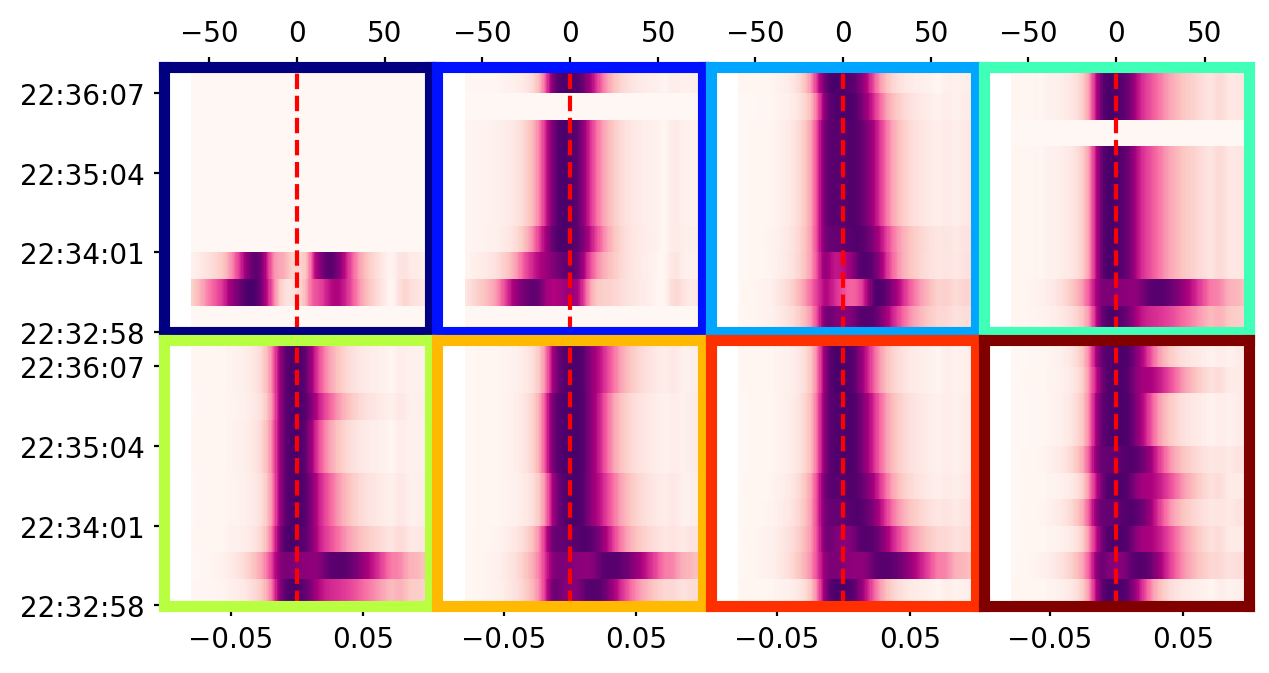

In [348]:
fig,ax=plt.subplots(2,4,figsize=(7,3.5),dpi=200)
lamb0=396.85
c=2.99e5
mu=1
for j in range(len(ls)):
    ax.flatten()[j].pcolormesh(selwls-lamb0,np.arange(0,10*91,91),arr_ev_pix[j,:,:],cmap='RdPu')
    ax.flatten()[j].set_xlim([396.75-lamb0,396.95-lamb0])
    ax.flatten()[j].set_yticks([])
    ax.flatten()[j].set_xticks([-0.05,0.05])
    ax.flatten()[j].axvline(0,c='red',linestyle='dashed')

    if j < 4:
       #ax.flatten()[j].set_xticks([]) 
       secaxx = ax.flatten()[j].secondary_xaxis('top', functions=(veltrans,wltrans))
       #secaxx.set_xlabel(r'Velocity $[km\; s^{-1}]$')
       #secaxx.set_xticks([-120,-80,-40,0,40,80,120])
    for spine in ax.flatten()[j].spines.values():
        spine.set_color(colors[j])
        spine.set_linewidth(4) # Optional: make it thicker

    ax.flatten()[j].xaxis.get_major_formatter().set_useOffset(False)

    if j == 0 or j == 4:
        ax.flatten()[j].set_yticks([(0*91)-45,(3*91)-45,(6*91)-45,(9*91)-45],labeltimes[0:10:3])
    else:
        ax.flatten()[j].set_yticks([])


fig.subplots_adjust(wspace=0.029)
fig.subplots_adjust(hspace=0.03)

In [349]:
# similar plotting but for kmeans - Hbeta
manyscan=1 # want to plot ~10 scans around the good-seeing scan

line=1 # this is just an index for Ca II H. In the .py file I used for the clustering, this is 1 if H-beta.  Don't worry about this key...
n_clusters0=35 # number of clusters
colors = plt.cm.turbo(np.linspace(0,1,n_clusters0)) #colormap for plotting

# define indices bounding the lines we could cluster
hbeta_low =353
hbeta_high = 640
caII_low = 480 #570 for first calibration pre March 6
caII_high = 690
hepsilon_low = 685
hepsilon_high = 810

#cutoff0 = 1.5 # for more than one frame
if line == 1:
    cutoff0=9 # for h-beta
    if manyscan:
        cutoff0=5 
if line == 0: # for ca II
    cutoff0=2.5
    if manyscan:
        cutoff0=2.5 

# number of clusters
if line == 1:
    n_clusters0 = 35 # 10 works for hbeta, 6 for Ca II H seems to be all that's needed, 6 also for h-ep
if line == 0:
    n_clusters0 = 35

#spatial limits (along slit) of ribbon -different for arms 1 and 2
if line == 1:
    startspace = 300 
    endspace = 1800 
if line == 0:
    startspace = 300 
    endspace = 1700
    
# define rest wavelengths
if line == 1:
    cent= 486.1375
if line == 0:
    cent = 396.85
    
# define limits of line; essentially the blue and red bounds of spectral range to cluster
if line == 1:
    linelow = hbeta_low
    linehigh = hbeta_high
if line == 0:
    linelow = caII_low
    linehigh = caII_high

# function to convert observed wavelength to velocity
def find_velocity(rest_wl,obs_wl):
    c= 299792458 # m/s
    
    return c*(obs_wl-rest_wl)/(obs_wl)

base = '/Users/coletamburri/Desktop/11Aug2024_kmeans_result_21May2026/' # change to directory you need


In [350]:
#load clustering file
km_file = np.load(base+'Hbeta_clustering_result.npz',allow_pickle='True')

#extract variables from clustering file
xarr_ch=km_file['xarr_ch'] # x coordinates for pcolormesh
yarr_ch=km_file['yarr_ch'] # y coordinates for pcolormesh
frame_line=km_file['frame_line'] # scans of interest, with along-slit direction limited just to what we want to see
normprofiles_line=km_file['normprofiles_line'] # normalized spectral line profiles
times=km_file['times'] # times for each ViSP slit position
km01=km_file['km0'] # numpy array containing the KMeansClusterer object (nltk)
labels0=km_file['labels0'] # numpy array containing the cluster number for each pixel
wave=km_file['wave'] # wavelength array for chosen arm
sortedinds=km_file['sortedinds'] # cluster indices sorted by weighted mean (blueshifted to redshifted
selwls=km_file['selwls'] # wavelength array for chosen line only
sortedwls=km_file['sortedwls'] # location of calculated line center (0 is the first index in "selwls")

#read pandas dataframe containing clusters from csv
# contains the mask info, including the x values, y values, and cluster number corresponding to each pixel
df_mask = pd.read_csv(base+'Hbeta_df.csv') 

#the result of kmeans is a weird class from the nltk package; extract the necessary info with this line
km0 = km01.item()   # extract the object so we can read variables directly as attributes of the class
cc = km0.cluster_centers_

/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator KMeans from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


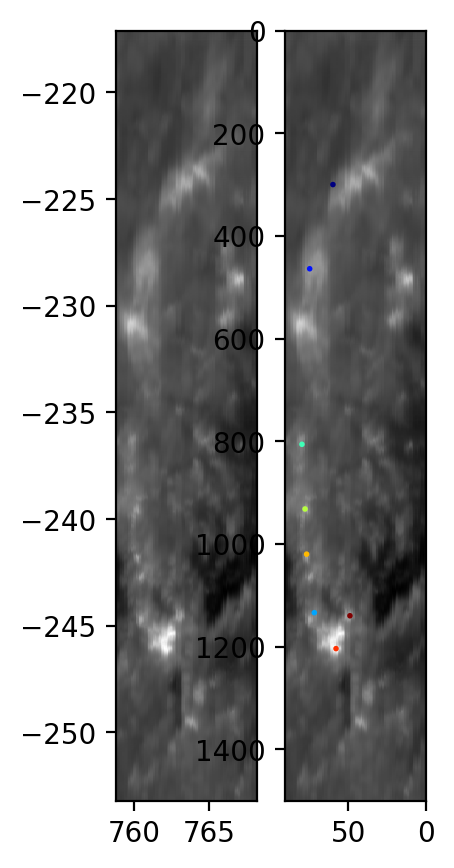

In [351]:
n_points = 8
colors = plt.cm.jet(np.linspace(0,1,n_points))
fig,ax=plt.subplots(1,2,dpi=200,figsize=(2,5))
axes=ax.flatten()
axes[0].pcolormesh(xarr_ch,yarr_ch,np.transpose(frame_line[(91):(91*(1+1)),:]),cmap='grey',alpha=1)
axes[1].pcolormesh(np.transpose(frame_line[(91):(91*(1+1)),:]),cmap='grey',alpha=1)
axes[1].invert_xaxis()
axes[1].invert_yaxis()
# axes[1].set_xticks([])
# axes[1].set_yticks([])
axes[1].scatter(x_other_inds,[x-300 for x in y_other_inds],1,color=colors)

In [352]:
pixkm = np.zeros((8,10))
arr_ev_pix = np.zeros((8,10,len(selwls)))
y_other_inds_adj = [x-300 for x in y_other_inds]
for j in range(10):
    for i in range(8):
        x = x_other_inds[i]
        y = y_other_inds_adj[i]
        mask = (df_mask['x'] == x+(91*j)) & (df_mask['y'] == y)
        if len(df_mask[mask])>0:
            pixkm[i,j]= int(df_mask[mask]['dist'].item())
        else:
            pixkm[i,j]=np.nan

for i in range(8):
    for j in range(10):
        if pixkm[i,j] >-1:
            arr_ev_pix[i,j,:]=cc[sortedinds[int(pixkm[i,j])]]
            

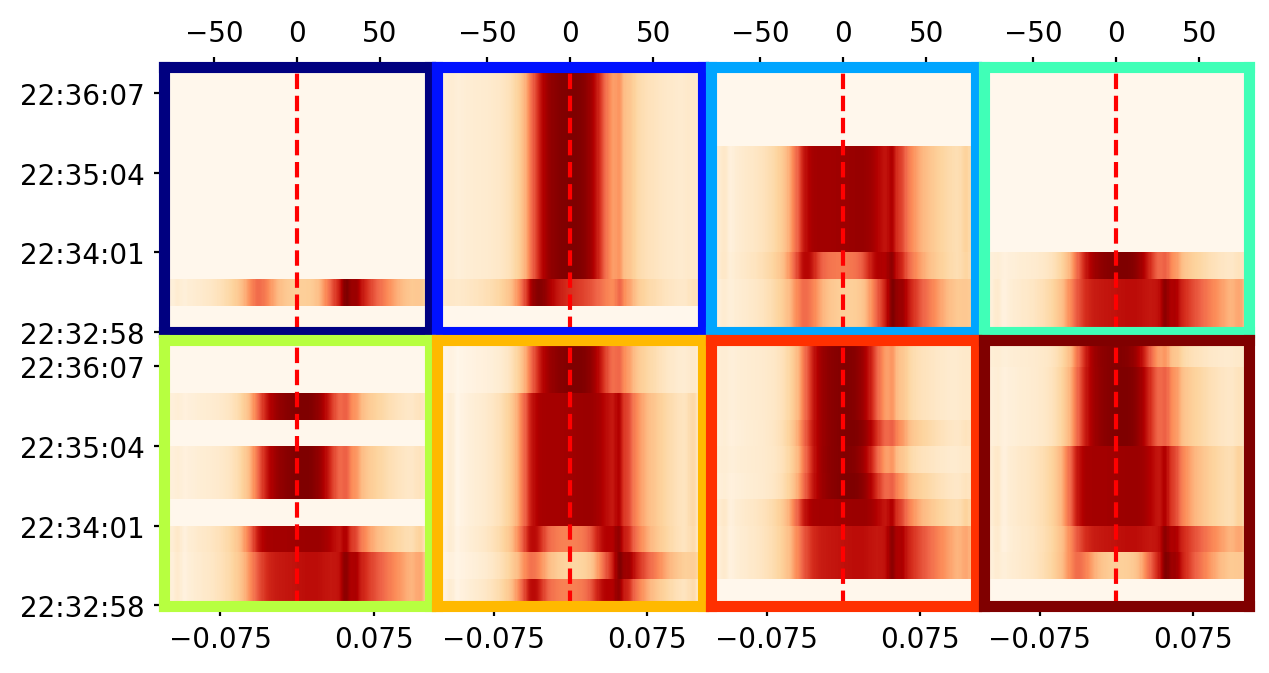

In [353]:
fig,ax=plt.subplots(2,4,figsize=(7,3.5),dpi=200)
lamb0=486.1375
c=2.99e5
mu=1
for j in range(len(ls)):
    ax.flatten()[j].pcolormesh(selwls-lamb0,np.arange(0,10*91,91),arr_ev_pix[j,:,:],cmap='OrRd')
    ax.flatten()[j].set_xlim([-0.13,0.13])
    ax.flatten()[j].set_yticks([])
    ax.flatten()[j].set_xticks([-0.075,0.075])
    ax.flatten()[j].axvline(0,c='red',linestyle='dashed')

    if j < 4:
       #ax.flatten()[j].set_xticks([]) 
       secaxx = ax.flatten()[j].secondary_xaxis('top', functions=(veltrans,wltrans))
       #secaxx.set_xlabel(r'Velocity $[km\; s^{-1}]$')
       #secaxx.set_xticks([-120,-80,-40,0,40,80,120])
    for spine in ax.flatten()[j].spines.values():
        spine.set_color(colors[j])
        spine.set_linewidth(4) # Optional: make it thicker

    ax.flatten()[j].xaxis.get_major_formatter().set_useOffset(False)

    if j == 0 or j == 4:
        ax.flatten()[j].set_yticks([(0*91)-45,(3*91)-45,(6*91)-45,(9*91)-45],labeltimes[0:10:3])
    else:
        ax.flatten()[j].set_yticks([])


fig.subplots_adjust(wspace=0.029)
fig.subplots_adjust(hspace=0.03)

In [56]:
n_points = 10
colors = plt.cm.jet(np.linspace(0,1,n_points))


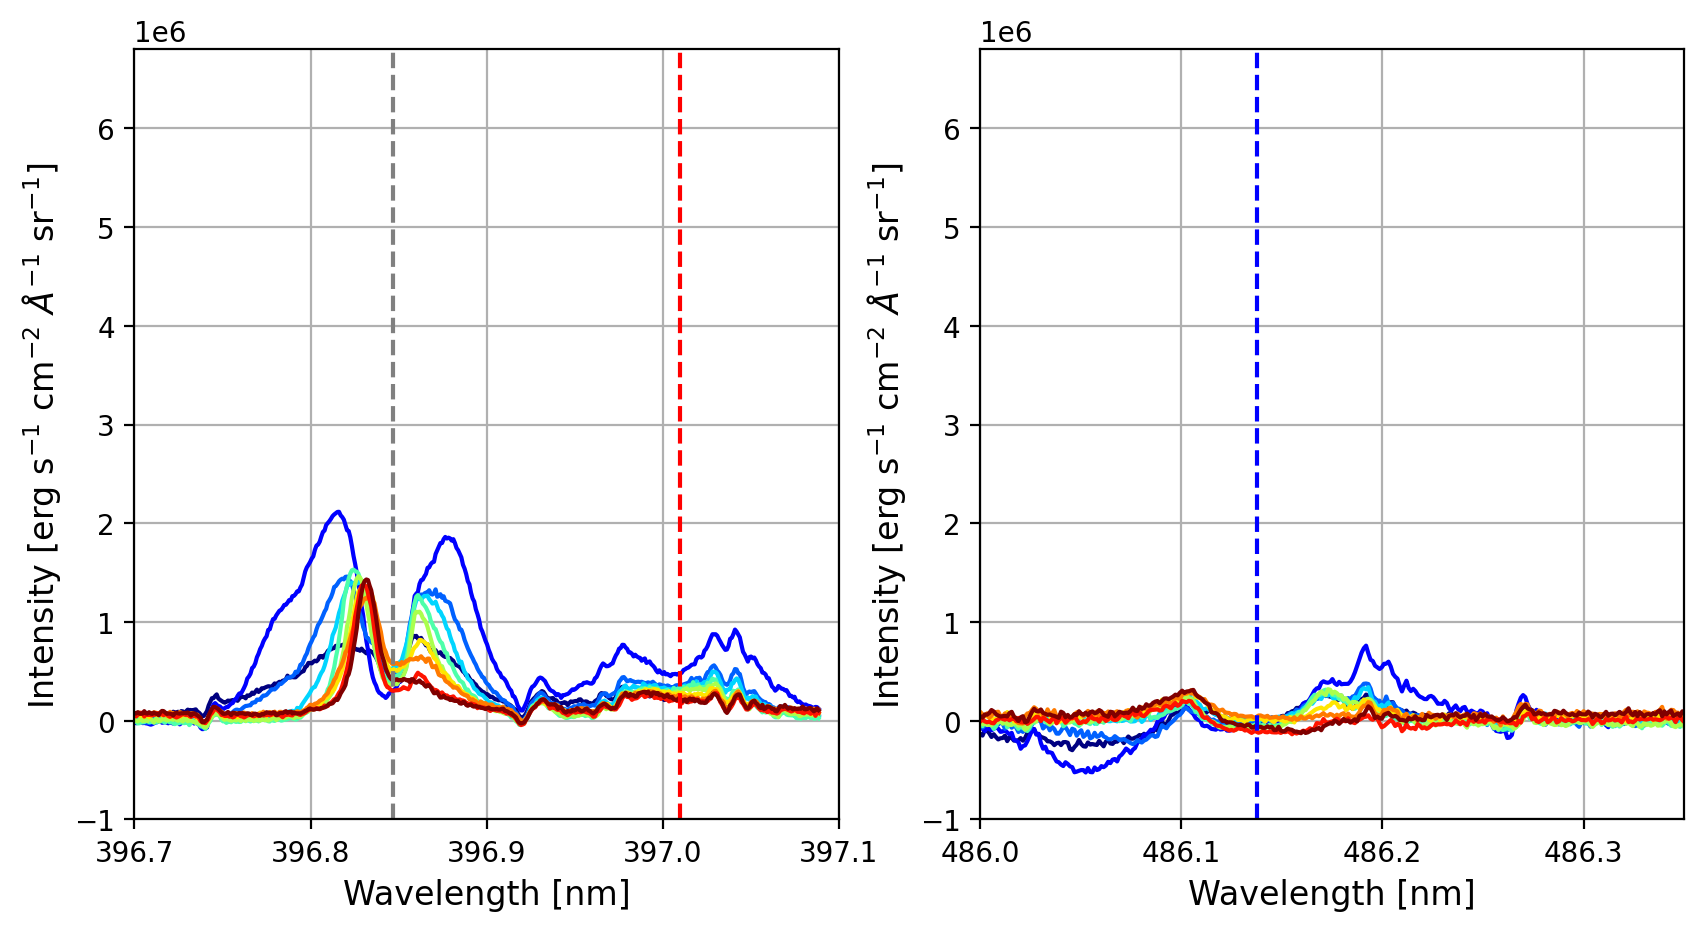

In [89]:
i = 9

xch = xsel[i]
ych = ysel[i]
#plot with ViSP time series

# ID VISP coord

caII_xc = xarr_caII[xch]
caII_yc = yarr_caII[ych]

#get vbi blue coordinates
xchhbeta, hb_xc = find_nearest(xarr_hbeta,caII_xc)
ychhbeta, hb_yc = find_nearest(yarr_hbeta,caII_yc)

fig,ax=plt.subplots(1,2,figsize=(10,5),dpi=200)

for j in range(-1,9,1):
    ax.flatten()[0].plot(wave_caII,flare_arr_caII[148+xch+91*j,:,ych],color=colors[j+1])
    ax.flatten()[1].plot(wave_hbeta,flare_arr_hbeta[148+xchhbeta+91*j,:,ychhbeta],color=colors[j+1])

ax.flatten()[0].set_xlim([396.7,397.08])
ax.flatten()[1].set_xlim([486.0,486.35])
ax.flatten()[0].set_ylim([-1e6,6.8e6])
ax.flatten()[1].set_ylim([-1e6,6.8e6])

ax.flatten()[0].axvline(396.847,linestyle='dashed',color='grey')
ax.flatten()[0].axvline(397.01,linestyle='dashed',color='red')
ax.flatten()[1].axvline(486.1375,linestyle='dashed',color='blue')




ax.flatten()[0].set_xlabel('Wavelength [nm]',fontsize=12)
ax.flatten()[0].set_ylabel(r'Intensity [erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$ sr$^{-1}$]',fontsize=12)

ax.flatten()[1].set_xlabel('Wavelength [nm]',fontsize=12)
ax.flatten()[1].set_ylabel(r'Intensity [erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$ sr$^{-1}$]',fontsize=12)

ax.flatten()[0].grid('on')
ax.flatten()[1].grid('off')

ax.flatten()[0].set_xticks([396.7,396.8,396.9,397,397.1])
ax.flatten()[1].set_xticks([486,486.1,486.2,486.3])





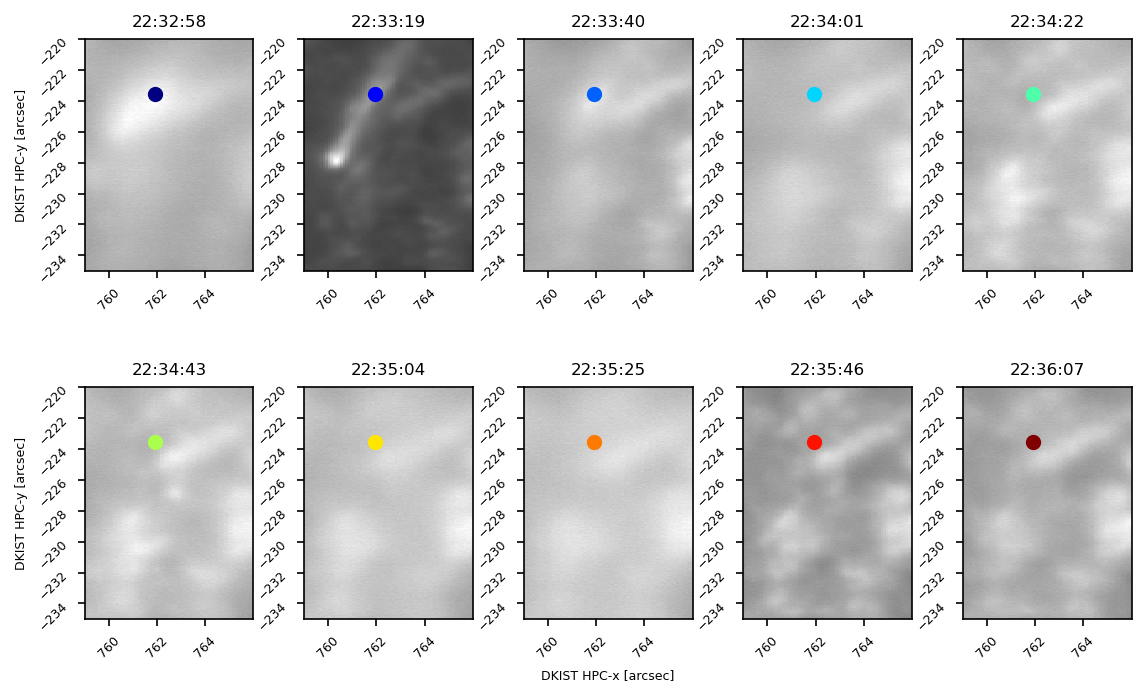

In [79]:
fig,ax=plt.subplots(2,5,figsize=(8,5),dpi=150)

if i == 3 or i == 4:
    ylo=-250
    yhi=-240
    xlo=759
    xhi=766

if i==0 or i ==1 or i==2 or i==5 or i ==6:
    ylo=-245
    yhi=-235
    xlo=759
    xhi=766

if i>6:
    ylo=-235
    yhi=-220
    xlo=759
    xhi=766

for j in range(10):
    if i<8:
        ax.flatten()[j].pcolormesh(xarr_caII[:-1],yarr_caII,np.transpose(flare_arr_caII[57+(91*j):56+(91*(j+1)),caII_high,:]),cmap='grey',alpha=1)
    else:
        ax.flatten()[j].pcolormesh(xarr_caII[:-1],yarr_caII,np.transpose(flare_arr_caII[57+(91*j):56+(91*(j+1)),caII_low,:]),cmap='grey',alpha=1)
   
    #xsel=xsel-lower_threshold+xlo

    ax.flatten()[j].scatter(caII_xc,caII_yc,40,color=colors[j],alpha=1,marker='o')

    #ax.flatten()[i].set_ylim([yhi,ylo])
    ax.flatten()[j].set_ylim([ylo,yhi])
    ax.flatten()[j].set_xlim([xlo,xhi])
    ax.flatten()[j].tick_params(axis='x', labelrotation=45)
    ax.flatten()[j].tick_params(axis='y', labelrotation=45)
    
    ax.flatten()[j].tick_params(axis='x',labelsize=6)
    ax.flatten()[j].set_xticks([760,762,764])
    ax.flatten()[j].tick_params(axis='y',labelsize=6)
    ax.flatten()[j].set_title(times[57+91*j][11:19],fontsize=8)
    #ax.flatten()[i].set_xticks([760,763,766])
ax.flatten()[0].set_ylabel('DKIST HPC-y [arcsec]',fontsize=6)
ax.flatten()[5].set_ylabel('DKIST HPC-y [arcsec]',fontsize=6)

ax.flatten()[7].set_xlabel('DKIST HPC-x [arcsec]',fontsize=6)
fig.tight_layout(pad=2.0) 
fig.subplots_adjust(hspace=0.5,wspace=0.3)

In [39]:
nonflare=np.load('/Users/coletamburri/Desktop/nonflareHbeta.npz')

In [40]:
nonflare


NpzFile '/Users/coletamburri/Desktop/nonflareHbeta.npz' with keys: nonflare, wl

In [41]:
nf = nonflare['nonflare']

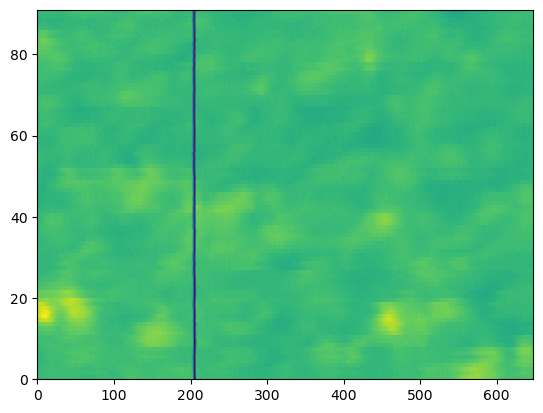

In [42]:
plt.pcolormesh(nf[:,700,:])

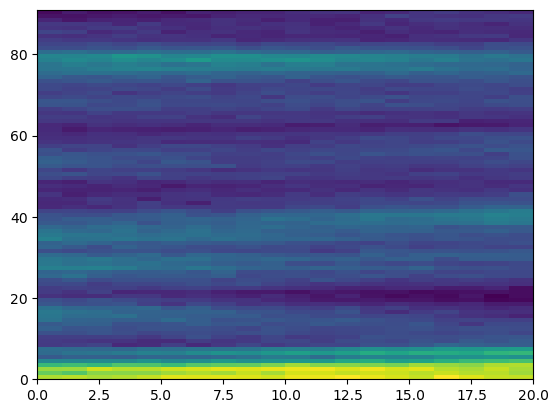

In [43]:
plt.pcolormesh(nf[:,700,560:580])

In [46]:
stavg1 = np.mean(np.mean(nf,axis=0),1)

In [47]:
stavg2 = np.mean(np.mean(nf[:,:,230:],axis=0),1)

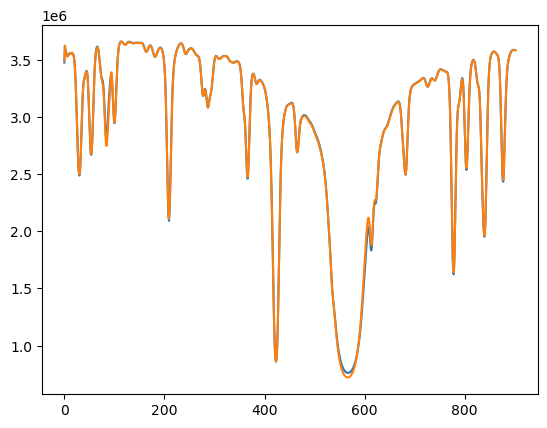

In [48]:
plt.plot(stavg1);plt.plot(stavg2)